<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcad_ex3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Prepare the dataset

In [28]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [29]:
#load dataset
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')

In [30]:
#remove unnecessary columns
df.drop(df.iloc[:,5:15], axis=1, inplace=True)

In [31]:
#rename column
df.rename(columns={'Sum of Run1_number_all':'Total_fish_individuals'}, inplace=True)

In [32]:
#remove missing values
df2 = df.dropna()

In [33]:
#identify the 4 catchments with most sites
top4 = df2['Catchment_name'].value_counts().head(4).index
print(top4)

Index(['Galiza-Norte', 'Minho', 'Cantabrica', 'Douro'], dtype='object', name='Catchment_name')


##2. Strip plots

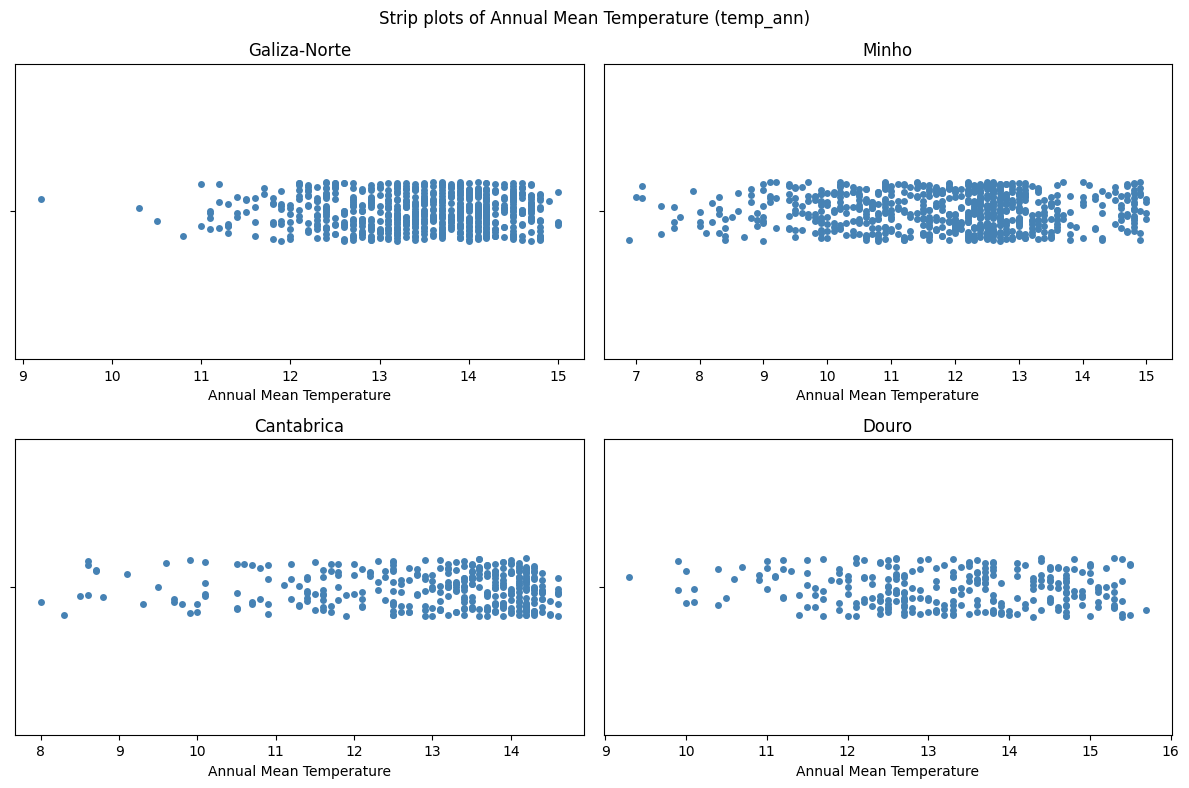

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, catchment in enumerate(top4):

    data = df2[df2["Catchment_name"] == catchment]

    ax = axes[i//2, i%2]

    sns.stripplot(
        x=data["temp_ann"],
        ax=ax,
        color="steelblue",
        jitter=True
    )

    ax.set_title(catchment)
    ax.set_xlabel("Annual Mean Temperature")

plt.suptitle("Strip plots of Annual Mean Temperature (temp_ann)")
plt.tight_layout()
plt.show()

The strip plot shows the individual values of the annual mean temperature (temp_ann) for the four catchments that have the most number of fish sampling sites. Each point represents one observation, and we are able to visualize the distribution of the temperatures within the catchments.

It shows the distribution of the values and highlights the presence of clusters and possibly the presence of any outlying values. However, when the number of values is large, the plot is difficult to interpret because of the presence of overlapping points. Therefore, strip plots are most effective for small to medium-sized datasets.

**Pros**

- Shows every individual observation

- Good for detecting clusters or gaps

- Easy to understand

**Cons**

- Becomes cluttered with large datasets

- Hard to see distribution shape clearly

##3. Histograms

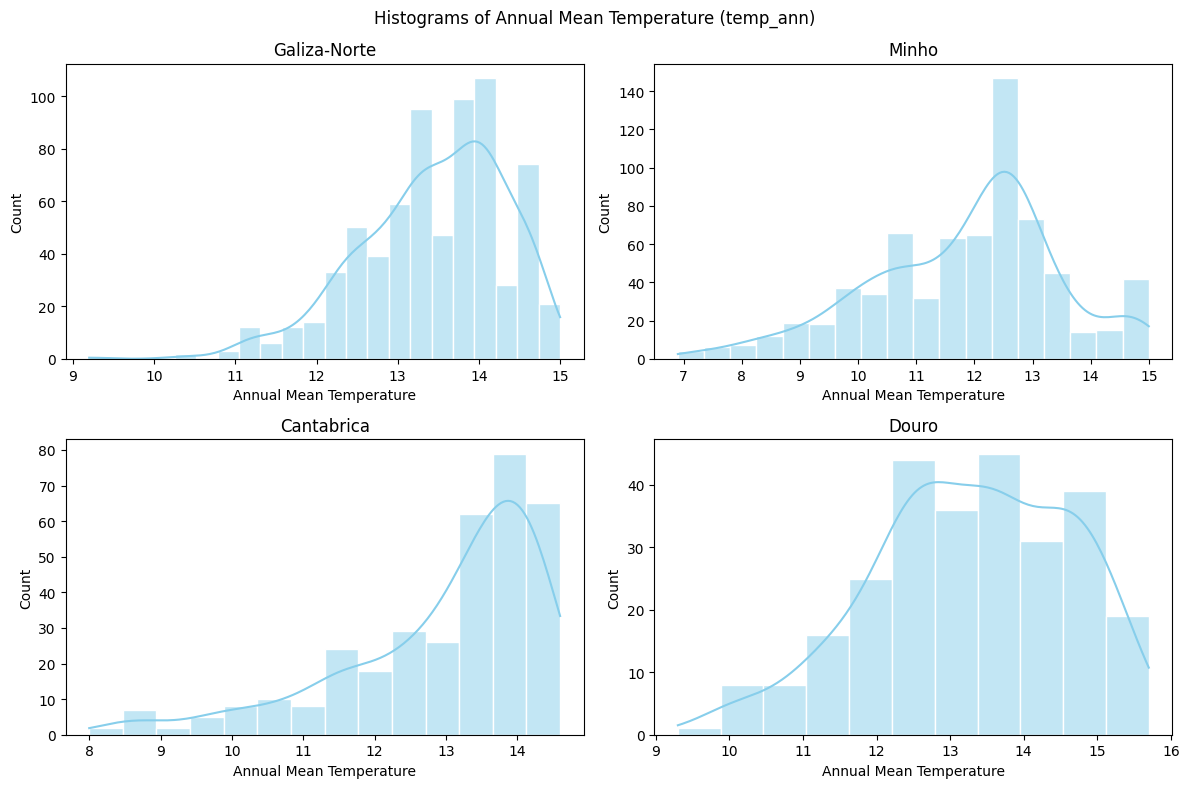

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, catchment in enumerate(top4):

    data = df2[df2["Catchment_name"] == catchment]

    ax = axes[i//2, i%2]

    sns.histplot(
        data["temp_ann"],
        kde=True,
        ax=ax,
        color="skyblue",
        edgecolor="white"
    )

    ax.set_title(catchment)
    ax.set_xlabel("Annual Mean Temperature")

plt.suptitle("Histograms of Annual Mean Temperature (temp_ann)")
plt.tight_layout()
plt.show()

Histograms show a distribution of the frequency of mean temperatures for a given catchment area. The visualization enables us to see the distribution pattern of data, which could be symmetric, skewed, or bimodal.

In comparison to strip plots, it is easier to see a distribution pattern of data using histograms. However, it is important to note that histograms are dependent on bin size. In spite of this limitation, it is one of the most effective visualization tools for quantitative data distribution.

**Pros**

- Shows the distribution of the data

- Easy to identify skewness and modality

- Good for large datasets

**Cons**

- Sensitive to bin size

- Exact individual values are lost

##4. Boxplots

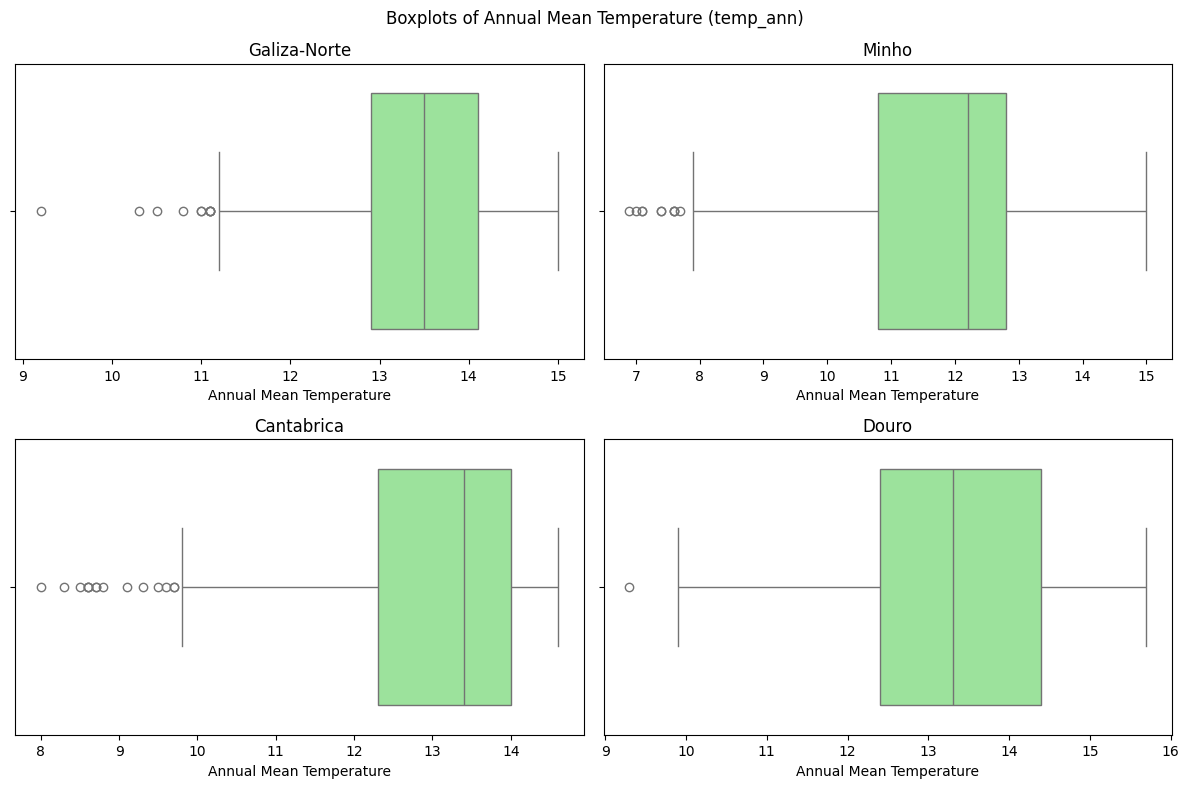

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, catchment in enumerate(top4):

    data = df2[df2["Catchment_name"] == catchment]

    ax = axes[i//2, i%2]

    sns.boxplot(
        x=data["temp_ann"],
        ax=ax,
        color="lightgreen"
    )

    ax.set_title(catchment)
    ax.set_xlabel("Annual Mean Temperature")

plt.suptitle("Boxplots of Annual Mean Temperature (temp_ann)")
plt.tight_layout()
plt.show()

Boxplots describe the distribution of the variable temp_ann based on important statistical properties that include the median and quartiles. This enables the comparison of the catchments and the compact presentation of the data.

The boxplot is advantageous since it presents the central tendency and variability of the data. However, it fails to show the exact distribution of the data and may conceal the presence of modes within the data.

**Pros**

- Summarizes distribution using median, quartiles, and outliers

- Very effective for comparing groups

- Compact representation

**Cons**

- Does not show the full distribution

- Can hide multimodal patterns

##5. Violin plots

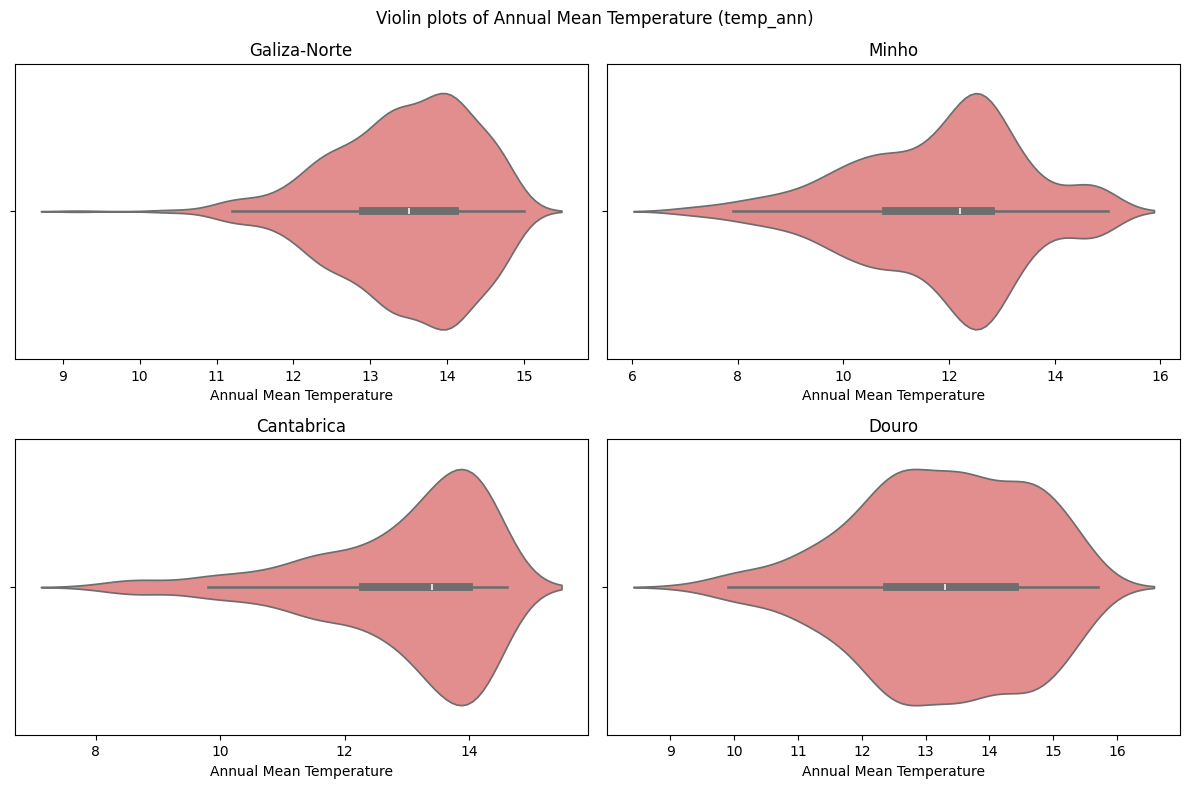

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, catchment in enumerate(top4):

    data = df2[df2["Catchment_name"] == catchment]

    ax = axes[i//2, i%2]

    sns.violinplot(
        x=data["temp_ann"],
        ax=ax,
        color="lightcoral"
    )

    ax.set_title(catchment)
    ax.set_xlabel("Annual Mean Temperature")

plt.suptitle("Violin plots of Annual Mean Temperature (temp_ann)")
plt.tight_layout()
plt.show()

Violin plots are a combination of box plots and density plots. This gives a better idea of the distribution of temperature values for each catchment.
Although violin plots are very informative, they might be less easy for people who are not familiar with density plots.

It combines distribution + density, making it very informative.

**Pros**

- Shows full distribution shape

- Combines density + summary statistics

- More informative than boxplots

**Cons**

- Harder to interpret for beginners

- Requires larger sample sizes

##6. Random sampling experiment (1000 samples)

**Goal:** show how sample size affects the estimate of the mean temperature.

In [38]:
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]

results = []

for n in sample_sizes:

    means = []

    for i in range(1000):

        sample = df2["temp_ann"].sample(n=n, replace=True)
        means.append(sample.mean())

    results.append(means)

In [39]:
#convert to dataframe
results_df = pd.DataFrame(results).T
results_df.columns = sample_sizes

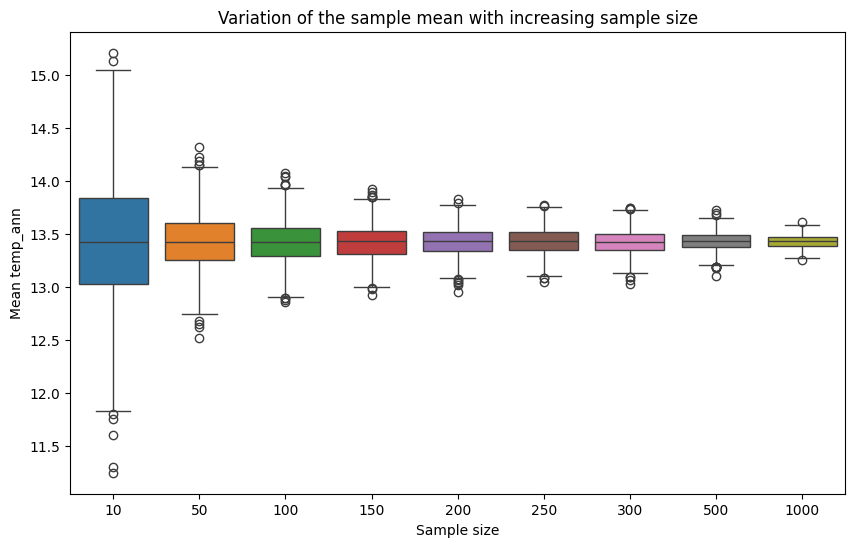

In [40]:
#visualization of the sampling experiment
plt.figure(figsize=(10,6))

sns.boxplot(data=results_df)

plt.xlabel("Sample size")
plt.ylabel("Mean temp_ann")
plt.title("Variation of the sample mean with increasing sample size")

plt.show()

The experiment of simulating a random sample shows the effect of sample size increase on the estimate of mean temperature.

When the sample size is low, the sample means vary significantly from each other. This shows that there is a lot of uncertainty associated with the estimate.

As the sample size is increased, the sample means tend to converge to a single estimate. This shows that as sample size increases, estimates converge to a single estimate. This illustrates the law of large numbers.

- Small samples → large variability of the mean

- Large samples → means converge to the population mean

**Conclusion:**

Histograms are the best visualization for understanding distribution shape, boxplots are best for comparing distributions across groups, while strip plots are useful for visualizing individual observations but become less effective with large datasets.

Overall, combining different visualization methods provides a more complete understanding of the distribution of environmental variables, since each plot highlights different aspects of the data.